# Getting Started with cleanskate

**cleanskate** is a Python package to access clean figure skating data. Results are parsed from ISU protocols and stored on the cloud, and downloaded

The main 
To load data, import the `Dataset` handler from `cleanskate. The object supports methods for loading events, overall results, elements, and program component scores.

In [1]:
import pandas as pd

from cleanskate import Dataset

ds = Dataset()

events = ds.load_events()
results = ds.load_results()
segments = ds.load_segments()
elements = ds.load_elements()
components = ds.load_program_components()

print(f'Events: {len(events)}')
print(f'Segments: {len(segments)}')
print(f'Results: {len(results)}')
print(f'Participants: {len(results["name"].unique())}')
print(f'Elements: {len(elements)}')


Events: 132
Segments: 1078
Results: 17924
Participants: 2108
Elements: 152811


## Standings


In [2]:
standings = ds.load_standings()

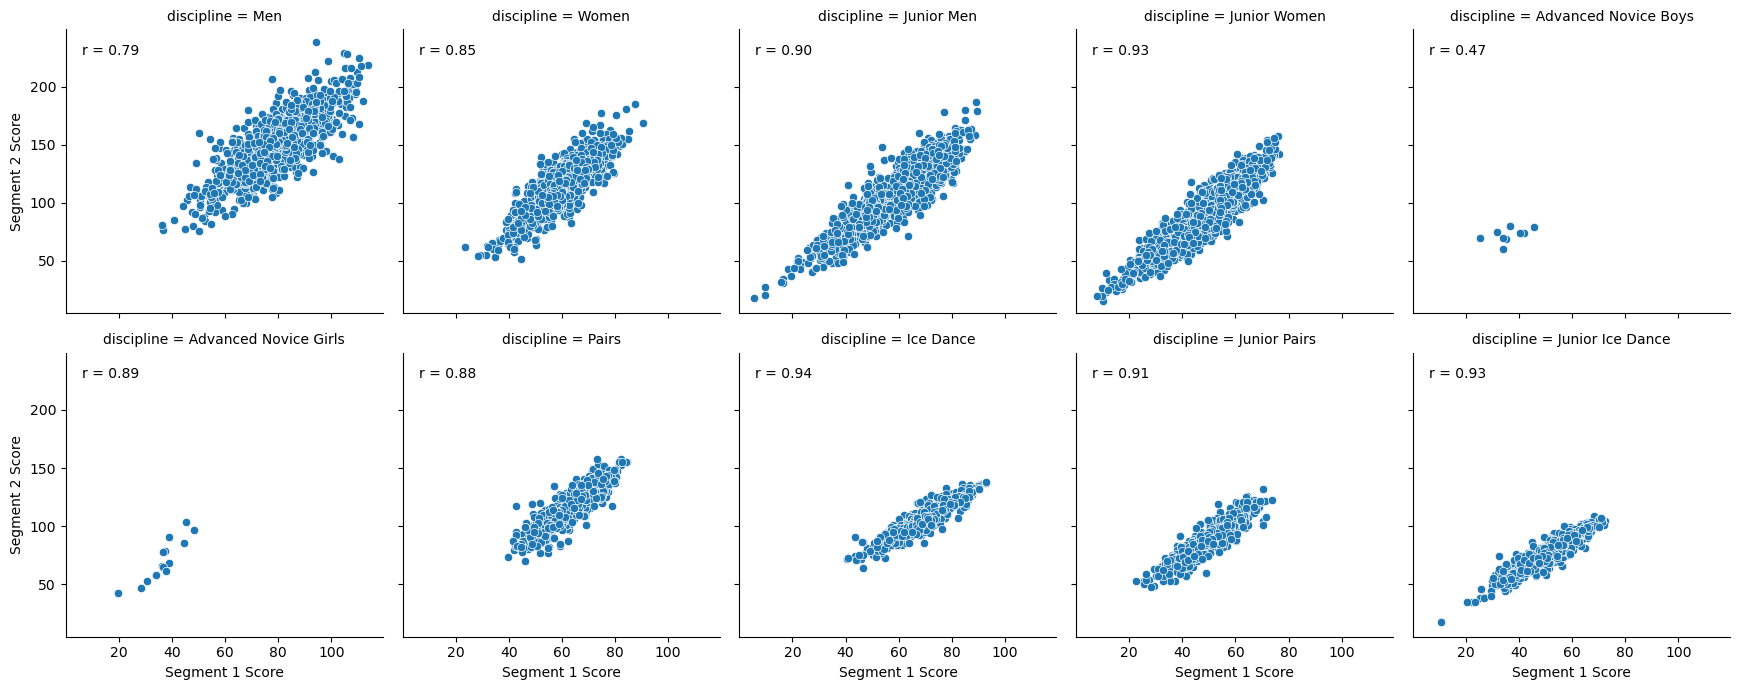

In [3]:
import matplotlib as mpl
import seaborn as sns
import numpy as np

mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

def annotate_corr(data, **kws):
    subset = data[['segment_1_score', 'segment_2_score']].dropna()
    x = subset['segment_1_score']
    y = subset['segment_2_score']
    
    if len(subset) > 1 and x.nunique() > 1 and y.nunique() > 1:
        r = np.corrcoef(x, y)[0, 1]
        label = f"r = {r:.2f}"
    else:
        label = "r = NA"
    
    ax = mpl.pyplot.gca()
    ax.text(
        0.05, 0.95,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top'
    )

g = sns.relplot(
    data=standings,
    x='segment_1_score',
    y='segment_2_score',
    col='discipline',
    height=3.5,  
    aspect=1,
    col_wrap=5
    )

g.map_dataframe(annotate_corr)
g.set_axis_labels("Segment 1 Score", "Segment 2 Score")

## Skater performance per element

We can subset the elements data frame to identify who gets the highest scores on particular elements. Let's start by focusing on the triple axel.

In [4]:
import numpy as np

elements_3a = ds.load_elements(attempt_code='3A')
skater_scores_3a = elements_3a.groupby('name', as_index=False).agg(
    count=('goe', len),
    mean_goe=('goe', lambda x: sum(x)/len(x)),
    prob_clean=('info_flags', lambda x: np.mean(pd.isna(x))),
    prob_fall=('info_flags', lambda x: np.mean(~pd.isna(x) & x.str.contains('F')))
    )

skater_scores_3a[ skater_scores_3a['count'] >= 10].sort_values(by='mean_goe', ascending=False).head(10)

,name,count,mean_goe,prob_clean,prob_fall
294,Yuzuru HANYU,14,2.275714,0.928571,0.000000
204,Nathan CHEN,23,2.042609,1.000000,0.000000
110,Ilia MALININ,39,1.882051,1.000000,0.000000
248,Shoma UNO,42,1.571905,0.952381,0.000000
197,Mikhail KOLYADA,12,1.371667,1.000000,0.000000
231,Rio NAKATA,19,1.334737,0.947368,0.052632
291,Yuma KAGIYAMA,48,1.248125,0.937500,0.041667
199,Minkyu SEO,17,1.236471,0.882353,0.117647
249,Shun SATO,37,1.179189,0.972973,0.027027
143,Keiji TANAKA,14,1.124286,1.000000,0.000000


## Best elements for a skater

Another way to dice this data is to examine which elements generally get the most points for a skater. We can use the filtering in `load_elements` to subset to particular combinations and types of elements, and then inspect the expected number of points the skater will be awarded.

Let's try Ilia Malinin for an example.

In [5]:
senior_jumps = ds.load_elements(event_level="Senior", element_family=["Jump", "Jump Combo", "Jump Sequence"])

ilia_elements = senior_jumps[ senior_jumps['name'] == 'Ilia MALININ' ].copy()
jump_counts = ilia_elements.groupby(['element_family', 'attempt_code'], as_index=False).agg(
    count=('goe', len),
    mean_goe=('goe', np.mean),
    mean_points=('panel_score', np.mean),
    prob_clean=('info_flags', lambda x: np.mean(pd.isna(x))),
    prob_fall=('info_flags', lambda x: np.mean(~pd.isna(x) & x.str.contains('F')))
    ).sort_values(by='mean_points', ascending=False)  

jump_counts = jump_counts[ jump_counts['count'] >= 5].sort_values(by='mean_points', ascending=False)
jump_counts

,element_family,attempt_code,count,mean_goe,mean_points,prob_clean,prob_fall
31,Jump Sequence,4S+3A+SEQ,6,0.938333,20.408333,0.833333,0.000000
19,Jump Combo,4Lz+3T,12,3.070833,19.606667,0.916667,0.000000
29,Jump Sequence,3Lz+3A+SEQ,5,1.578000,16.868000,1.000000,0.000000
27,Jump Combo,4T+3T,11,1.407273,16.228182,0.909091,0.000000
11,Jump,4Lz,14,3.557143,15.057143,1.000000,0.000000
9,Jump,4F,20,3.312000,14.312000,0.900000,0.000000
8,Jump,4A,5,1.002000,13.502000,0.600000,0.000000
14,Jump,4T,9,1.898889,11.504444,0.888889,0.111111
13,Jump,4S,8,1.652500,10.677500,0.750000,0.000000
4,Jump,3A,26,2.230385,10.445769,1.000000,0.000000


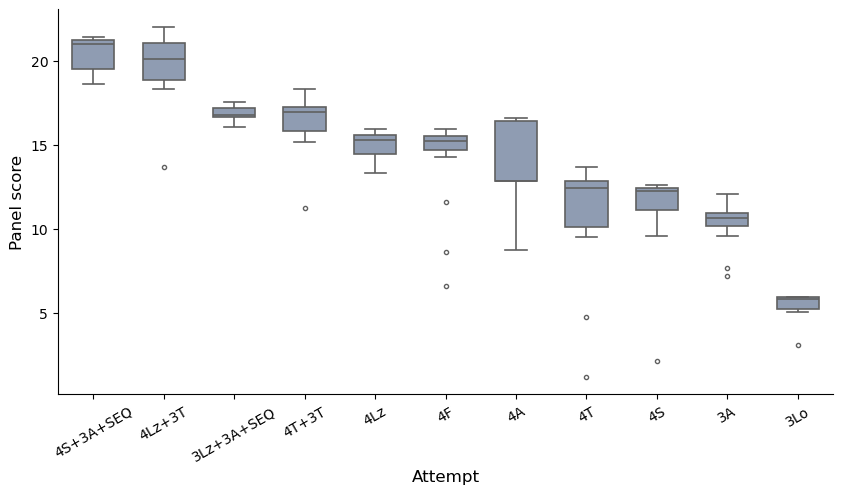

In [6]:
elements_to_keep = jump_counts['attempt_code'].values
plot_data = ilia_elements[ ilia_elements['attempt_code'].isin(elements_to_keep) ]

mpl.pyplot.figure(figsize=(10, 5))
ax = sns.boxplot(
    plot_data,
    x='attempt_code',
    y='panel_score',
    order=elements_to_keep,
    width=0.6,
    fliersize=3,            # smaller outliers
    linewidth=1.2,
    color="#899BB8"
    )

ax.set_xlabel("Attempt", fontsize=12)
ax.set_ylabel("Panel score", fontsize=12)
ax.tick_params(axis='x', rotation=30)

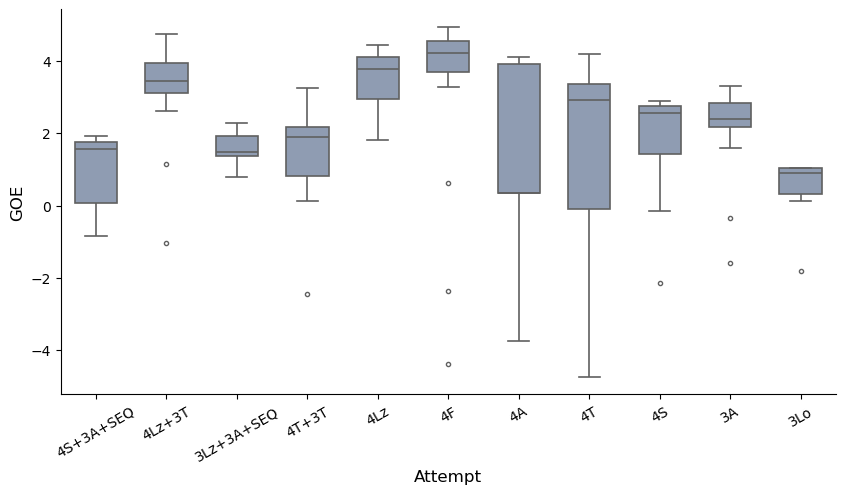

In [ ]:
mpl.pyplot.figure(figsize=(10, 5))
ax = sns.boxplot(
    plot_data,
    x='attempt_code',
    y='goe',
    order=elements_to_keep,
    width=0.6,
    fliersize=3,
    linewidth=1.2,
    color="#899BB8"
    )

ax.set_xlabel("Attempt", fontsize=12)
ax.set_ylabel("GOE", fontsize=12)
ax.tick_params(axis='x', rotation=30)

## Underrotators



In [ ]:
senior_jumps['rotation_issue'] = senior_jumps["quarter_called"] | senior_jumps["underrotated"] | senior_jumps["downgraded"]
underrotation_probabilities = senior_jumps.groupby('name', as_index=False).agg(
    total_jumps=('underrotated', len),
    prob_rotat=('underrotated', np.mean)
    )

underrotation_probabilities = underrotation_probabilities[ underrotation_probabilities['total_jumps'] >= 50 ].sort_values(by='prob_underrotated', ascending=False)
underrotation_probabilities

,name,total_jumps,prob_underrotated
264,Hongyi CHEN,100,0.490000
650,Vincent ZHOU,80,0.487500
342,Karen CHEN,90,0.444444
313,Josefin TALJEGARD,93,0.440860
522,Olga MIKUTINA,190,0.431579
...,...,...,...
119,Brendan KERRY,100,0.020000
396,Linnea CEDER,50,0.020000
406,Luc ECONOMIDES,110,0.018182
452,Maxim NAUMOV,70,0.014286


In [24]:
fx_df = elements[ elements['info_flags'] == 'Fx']

In [26]:
fx_df = fx_df[['event_label', 'segment_label', 'name']].merge(results)
fx_df

,event_label,segment_label,name,event_series,event_level,rank,noc,starting_number,total_segment_score,total_element_score,total_program_component_score,total_deductions,element_base_value_sum,element_panel_score_sum,program_component_score_factored,deduction_detail
0,57. Nebelhorn Trophy 2025,Pairs SP,Alisa EFIMOVA / Misha MITROFANOV,Challenger,Senior,3,USA,8,67.42,37.70,31.72,-2.0,32.30,37.70,31.72,Falls -2.00 (2) -2.00
1,57. Nebelhorn Trophy 2025,Pairs FS,Daria DANILOVA / Michel TSIBA,Challenger,Senior,13,NED,10,96.84,49.64,50.20,-3.0,51.50,49.64,50.20,Falls -3.00 (3) -3.00
2,Four Continents 2026,Ice Dance RD,Jamie FOURNIER / Everest ZHU,Four Continents,Senior,15,CAN,3,43.73,22.60,23.13,-2.0,26.38,22.60,23.13,Falls -2.00 (2) -2.00
3,NHK Trophy 2025,Ice Dance FD,Utana YOSHIDA / Masaya MORITA,Grand Prix,Senior,10,JPN,3,85.67,45.81,41.86,-2.0,43.54,45.81,41.86,Falls -2.00 (2) -2.00
4,Riga Cup 2024,Junior Ice Dance FD,Michelle DEYCH / Ryan HU,Junior Grand Prix,Junior,12,USA,10,65.68,31.76,35.92,-2.0,29.92,31.76,35.92,Falls -2.00 (2) -2.00
5,Solidarity Cup 2024,Junior Pairs SP,Reagan MOSS / Jakub GALBAVY,Junior Grand Prix,Junior,10,USA,12,39.47,21.02,20.45,-2.0,26.25,21.02,20.45,Falls -2.00 (2) -2.00
6,Solidarity Cup 2024,Junior Ice Dance FD,Lauren Audrey BATKOVA / Jacob YANG,Junior Grand Prix,Junior,18,CZE,5,61.27,33.13,30.14,-2.0,35.75,33.13,30.14,Falls -2.00 (2) -2.00
7,Solidarity Cup 2025,Junior Pairs FS,Zarah WOOD / Alex LAPSKY,Junior Grand Prix,Junior,18,GBR,4,56.75,29.28,31.47,-4.0,40.70,29.28,31.47,Falls -4.00 (4) -4.00
8,Ankara 2025,Junior Pairs FS,Polina POLMAN / Gabriel RENOLDI,Junior Grand Prix,Junior,14,ITA,10,59.96,29.48,35.48,-5.0,37.84,29.48,35.48,Time violation -1.00 Falls -4.00 (4) -5.00
